In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Create datafram from tournament results
df = pd.read_csv('tournaments.csv')
df.head()

,P1 [NS],P2 [EW],Score P1,Score P2,Seed
0,1,1,97,99,1
1,1,1,90,102,2
2,1,1,89,96,3
3,1,1,86,88,4
4,1,1,99,106,5


In [3]:
# Create scores by team
team_scores_NS = {}
team_scores_EW = {}
for i in range(1, 11):
    team_scores_NS[i] = df[df['P1 [NS]'] == i]['Score P1']
    team_scores_EW[i] = df[df['P2 [EW]'] == i]['Score P2']

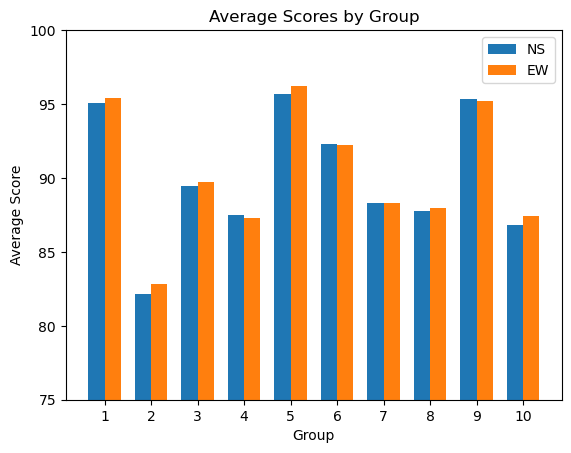

In [4]:
# Average scores by group
NS_avg_scores_by_group = {}
EW_avg_scores_by_group = {}
for i in range(1, 11):
    NS_avg_scores_by_group[i] = team_scores_NS[i].mean()
    EW_avg_scores_by_group[i] = team_scores_EW[i].mean()

# Plot bar chart of average scores by group
fig, ax = plt.subplots()
bar_width = 0.35
index = np.arange(1, 11)
rects1 = ax.bar(index, NS_avg_scores_by_group.values(), bar_width, label='NS')
rects2 = ax.bar(index + bar_width, EW_avg_scores_by_group.values(), bar_width, label='EW')
ax.set_ylim([75, 100])
ax.set_xlabel('Group')
ax.set_ylabel('Average Score')
ax.set_title('Average Scores by Group')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(index)
ax.legend()
plt.savefig('average_scores_by_group.png')
plt.show()

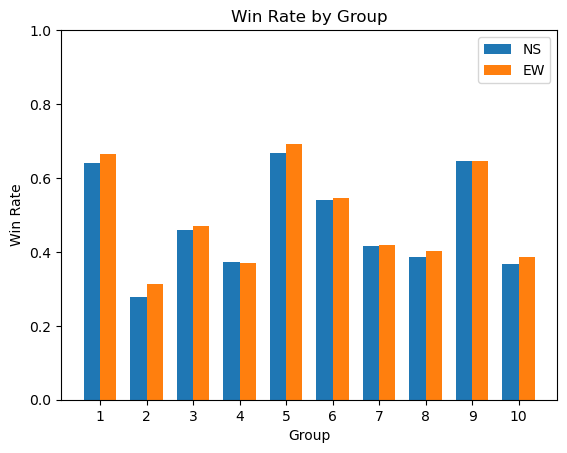

In [5]:
# Win rate by group
NS_win_rate_by_group = {}
EW_win_rate_by_group = {}
for i in range(1, 11):
    NS_win_rate_by_group[i] = (df[df['P1 [NS]'] == i]['Score P1'] > df[df['P1 [NS]'] == i]['Score P2']).sum() / len(df[df['P1 [NS]'] == i])
    EW_win_rate_by_group[i] = (df[df['P2 [EW]'] == i]['Score P2'] > df[df['P2 [EW]'] == i]['Score P1']).sum() / len(df[df['P2 [EW]'] == i])

# Plot bar chart of win rate by group
fig, ax = plt.subplots()
bar_width = 0.35
index = np.arange(1, 11)
rects1 = ax.bar(index, NS_win_rate_by_group.values(), bar_width, label='NS')
rects2 = ax.bar(index + bar_width, EW_win_rate_by_group.values(), bar_width, label='EW')
ax.set_ylim([0, 1])
ax.set_xlabel('Group')
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Group')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(index)
ax.legend()
plt.savefig('win_rate_by_group.png')
plt.show()